In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('sample_data/california_housing_train.csv')

df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [ ]:
X = df.drop('median_house_value', axis=1).values
y = df['median_house_value'].values

In [ ]:
# Standardization
mean = np.mean(X, axis=0)
std = np.std(X, axis=0)

X = (X - mean) / std

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
weights = np.zeros(X_train.shape[1])
bias = 0

In [ ]:
def train(X, y, lr, epochs):
    weights = np.zeros(X.shape[1])
    bias = 0

    for _ in range(epochs):
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)

        # gradients
        dw = (1 / len(y)) * np.dot(X.T, (y_pred - y))
        db = (1 / len(y)) * np.sum(y_pred - y)

        # update
        weights -= lr * dw
        bias -= lr * db

    return weights, bias

In [ ]:
def predict(X, weights, bias):
    linear_model = np.dot(X, weights) + bias
    y_pred = sigmoid(linear_model)

    return [1 if i > 0.5 else 0 for i in y_pred]

In [ ]:
def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def precision(y_true, y_pred):
    tp = sum((y_true == 1) & (y_pred == 1))
    fp = sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp + 1e-10)

def recall(y_true, y_pred):
    tp = sum((y_true == 1) & (y_pred == 1))
    fn = sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn + 1e-10)

In [ ]:
learning_rates = [0.01, 0.001]

for lr in learning_rates:
    print(f"\nLearning Rate: {lr}")

    weights, bias = train(X_train, y_train, lr, epochs=1000)
    y_pred = predict(X_test, weights, bias)

    print("Accuracy:", accuracy(y_test, y_pred))
    print("Precision:", precision(y_test, y_pred))
    print("Recall:", recall(y_test, y_pred))


Learning Rate: 0.01
Accuracy: 0.0
Precision: 0.0
Recall: 0.0

Learning Rate: 0.001
Accuracy: 0.0
Precision: 0.0
Recall: 0.0


In [ ]:
print("Sample Predictions:", y_pred[:10])

Sample Predictions: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [ ]:
def train(X, y, lr, epochs):
    weights = np.zeros(X.shape[1])
    bias = 0
    losses = []

    for _ in range(epochs):
        linear_model = np.dot(X, weights) + bias
        y_pred = sigmoid(linear_model)

        # Loss (Binary Cross Entropy)
        loss = -np.mean(y * np.log(y_pred + 1e-10) + (1 - y) * np.log(1 - y_pred + 1e-10))
        losses.append(loss)

        # gradients
        dw = (1 / len(y)) * np.dot(X.T, (y_pred - y))
        db = (1 / len(y)) * np.sum(y_pred - y)

        weights -= lr * dw
        bias -= lr * db

    return weights, bias, losses

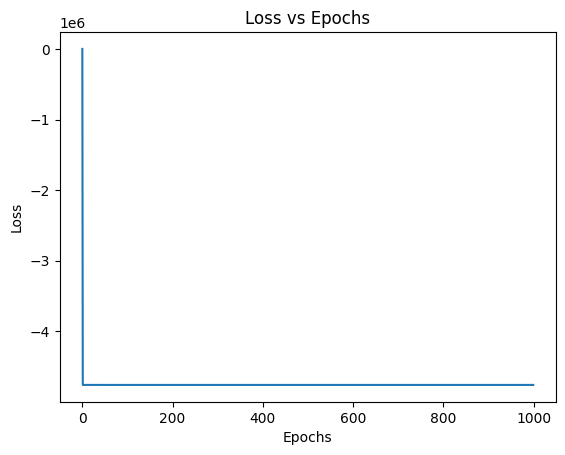

In [ ]:
import matplotlib.pyplot as plt

weights, bias, losses = train(X_train, y_train, lr=0.01, epochs=1000)

plt.plot(losses)
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

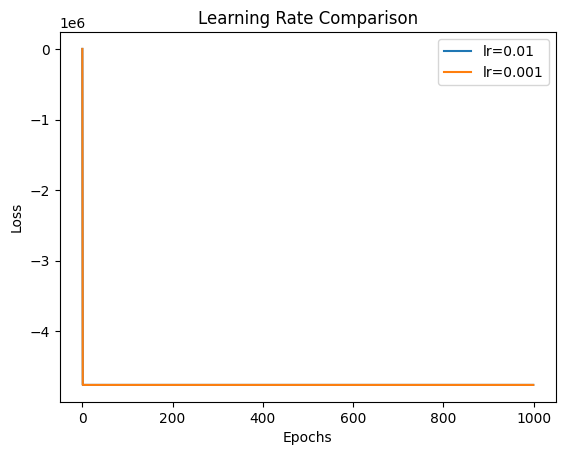

In [ ]:
for lr in [0.01, 0.001]:
    weights, bias, losses = train(X_train, y_train, lr=lr, epochs=1000)
    plt.plot(losses, label=f"lr={lr}")

plt.title("Learning Rate Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()